![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World!

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [1]:
import pandas as pd

In [4]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

FileNotFoundError: [Errno 2] No such file or directory: 'crimes.csv'

In [6]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [8]:
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [11]:

print(crimes.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  object
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(2), object(10)
memory usage: 17.0+ MB
None


In [13]:

print(crimes.describe())

              DR_NO       Vict Age
count  1.857150e+05  185715.000000
mean   2.255781e+08      39.999257
std    5.017438e+06      15.450227
min    2.009072e+08       2.000000
25%    2.210108e+08      28.000000
50%    2.220114e+08      37.000000
75%    2.310044e+08      50.000000
max    2.399097e+08      99.000000


In [15]:
print(crimes.isnull().sum())

DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex            11
Vict Descent        10
Weapon Desc     112213
Status Desc          0
LOCATION             0
dtype: int64


In [22]:
crimes['Vict Descent'].fillna('X', inplace=True)

In [23]:
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [25]:
crimes['Weapon Desc'].fillna('Unknown', inplace=True)

In [27]:
crimes['Vict Sex'].fillna('Unknown', inplace=True)

In [29]:
print(crimes.duplicated().sum())

0


In [35]:
column = 'Vict Age'

Q1 = crimes['Vict Age'].quantile(0.25)
Q3 = crimes['Vict Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = crimes[(crimes['Vict Age'] < lower_bound) | (crimes['Vict Age'] > upper_bound)]
print(outliers)

            DR_NO   Date Rptd    DATE OCC TIME OCC    AREA NAME  \
54      221511140  2022-06-14  2020-01-01     1235  N Hollywood   
116     221714096  2022-09-27  2020-01-09     1200   Devonshire   
119     221515500  2022-09-29  2020-09-01     0905  N Hollywood   
304     221610845  2022-07-26  2020-02-01     1200     Foothill   
314     221515089  2022-09-14  2020-01-01     1550  N Hollywood   
...           ...         ...         ...      ...          ...   
185302  230907157  2023-03-21  2023-03-17     1813     Van Nuys   
185339  230810854  2023-06-14  2023-06-08     0005      West LA   
185354  231507385  2023-03-21  2023-03-21     1900  N Hollywood   
185447  230900863  2023-05-27  2023-05-26     1600     Van Nuys   
185483  230114184  2023-06-13  2023-05-03     1400      Central   

                                     Crm Cd Desc  Vict Age Vict Sex  \
54                             THEFT OF IDENTITY        87        M   
116        CREDIT CARDS, FRAUD USE ($950 & UNDER     

In [40]:

crimes['TIME_OCC'] = crimes['TIME OCC'].astype(str).str.zfill(4)

crimes['TIME_OCC'] = crimes['TIME_OCC'].str[:2] + ':' + crimes['TIME_OCC'].str[2:]

print(crimes[['TIME OCC', 'TIME_OCC']].head())

  TIME OCC TIME_OCC
0     1110    11:10
1     1620    16:20
2     1200    12:00
3     0635    06:35
4     0900    09:00


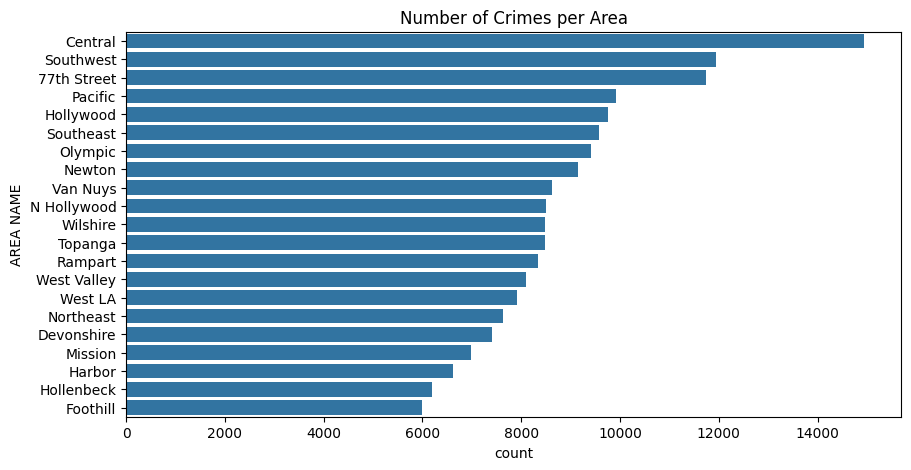

In [53]:
plt.figure(figsize=(10,5))
sns.countplot(y='AREA NAME', data=crimes, order=crimes['AREA NAME'].value_counts().index)
plt.title('Number of Crimes per Area')
plt.show()

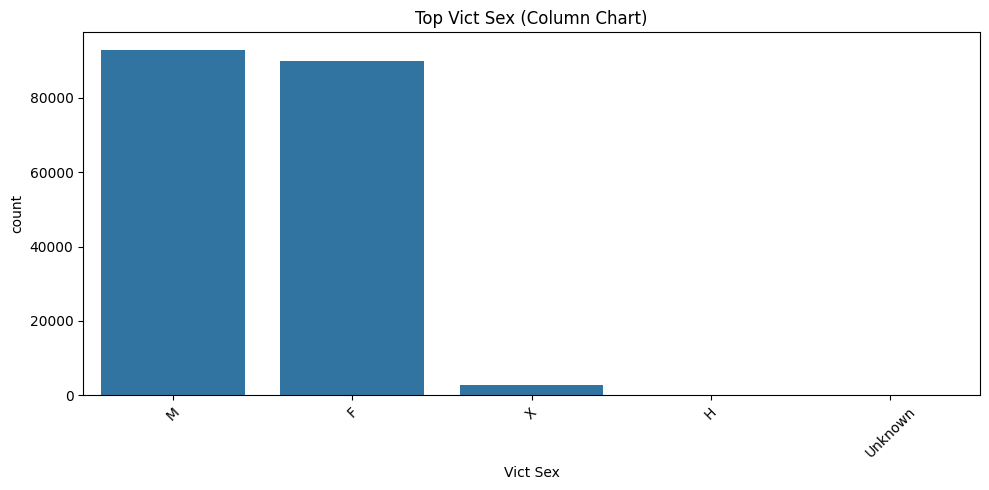

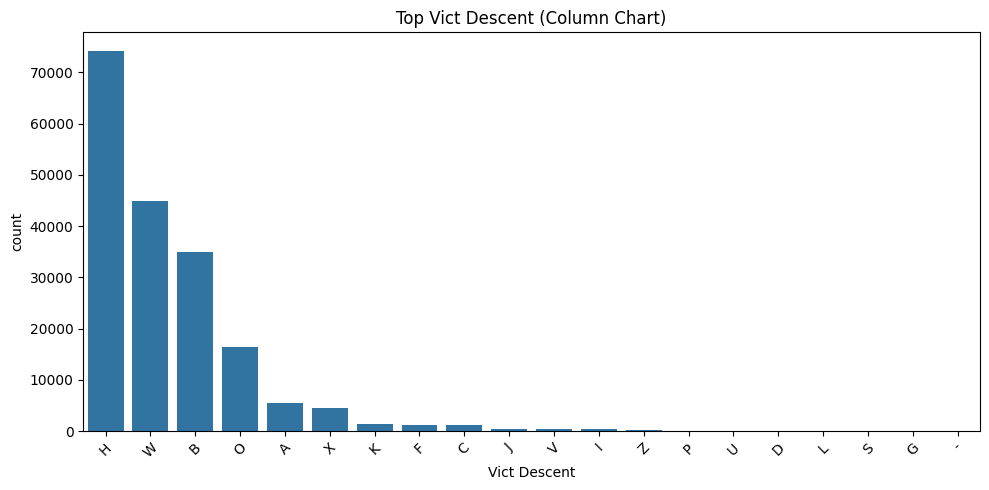

In [59]:
text_cols_col = ['Vict Sex', 'Vict Descent']
for col in text_cols_col:
    top_values = crimes[col].value_counts().head(20).index
    plt.figure(figsize=(10,5))
    sns.countplot(x=col, data=crimes, order=top_values)
    plt.title(f'Top {col} (Column Chart)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

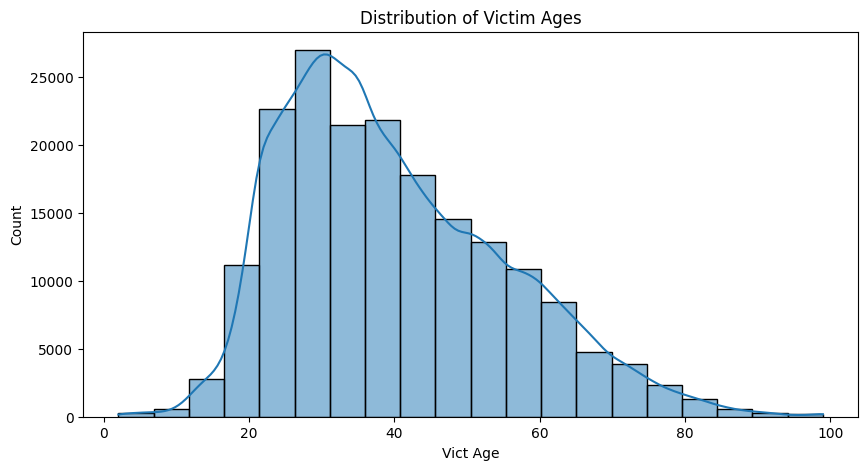

In [62]:
plt.figure(figsize=(10,5))
sns.histplot(crimes['Vict Age'], bins=20, kde=True)
plt.title('Distribution of Victim Ages')
plt.show()